# OS Analysis

**This notebook analyzes overall survival in patients with metastatic clear cell RCC treated with first-line combination immunotherapy or single-agent antiangiogenic therapy.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/ioio_tki_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate
3950,F3172237295D5,tki,2015-05-26
3447,F7E5B473EF042,tki,2017-06-01
1216,F4BB8833FA25D,tki,2013-01-18


In [4]:
treatment_df.shape

(4831, 3)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'ioio').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/ioio_tki_features.csv', dtype = dtype_map)

In [7]:
features_df.shape

(4366, 161)

In [8]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [9]:
df.shape

(4366, 164)

In [10]:
df = df.query('met_diagnosis_year <= 2020')

In [11]:
df.shape

(4193, 164)

## Survival analysis with IPTW

In [12]:
df.treatment.value_counts()

treatment
0    3421
1     772
Name: count, dtype: int64

In [13]:
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.288804
1    0.534974
Name: event, dtype: float64

In [14]:
estimator = IPTWSurvivalEstimator()

In [15]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['GroupStage'],
              cont_var = ['days_diagnosis_to_met', 'age', 'ecog_index', 'weight_index', 'percent_change_weight', 'albumin', 'creatinine', 'calcium', 'neutrophil', 'platelet', 'hemoglobin', 'van_walraven_score'],
              binary_var = ['Nephrectomy_mod', 'ecog_index_na', 'SmokingStatus', 'commercial', 'medicaid', 'days_to_treatment_before_1y'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [16]:
iptw_df = estimator.transform()

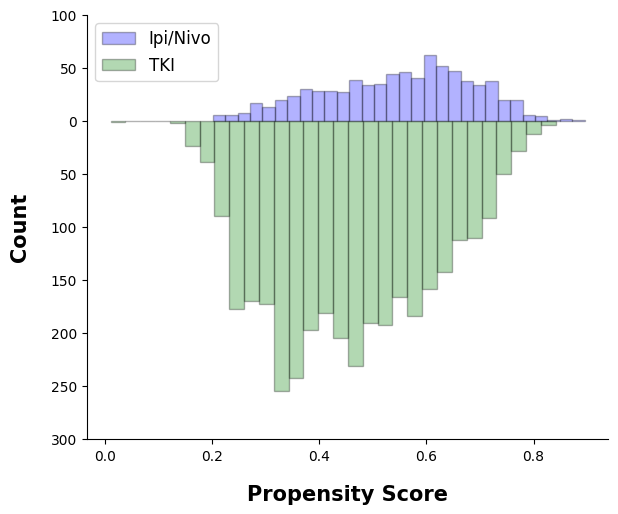

In [17]:
ps_fig = estimator.propensity_score_plot(bins = 30)

ax = ps_fig.axes[0]

ax.set_xlabel('Propensity Score', fontsize = 15)
ax.set_ylabel('Count', fontsize = 15)
ax.set_title('')
ps_fig.set_size_inches(6, 6)

handles, labels = ax.get_legend_handles_labels()
label_map = {'Treatment': 'Ipi/Nivo', 'Control': 'TKI'}
ax.legend(handles, [label_map.get(l, l) for l in labels], prop={'size': 12})

ps_fig.savefig('../outputs/ps_plot.pdf', dpi=300, bbox_inches='tight')
ps_fig

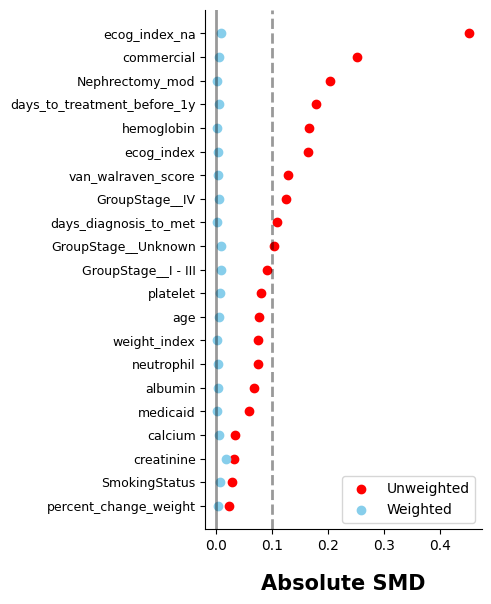

In [18]:
_, smd_fig = estimator.standardized_mean_differences(return_fig = True)

ax = smd_fig.axes[0]

# Resize figure
smd_fig.set_size_inches(4, 6)

# Axis/title font sizes
ax.set_xlabel('Absolute SMD', fontsize=15)
ax.set_title('')

# Reference line styles
for line in ax.lines:
    line.set_alpha(0.4)

ax.tick_params(axis='y', labelsize=9)
ax.legend(prop={'size': 10})
smd_fig.savefig('../outputs/smd_plot_os.pdf', dpi=300, bbox_inches='tight')
smd_fig

In [19]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42)

In [20]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [365, 730, 1095],
                                     rmst_time_points = [365, 730, 1095],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [21]:
# Median results
print('Median survival results')
print(f'IO-TKI: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'IO-IO: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
IO-TKI: (26.3, 23.2, 31.0) months
IO-IO: (22.9, 21.7, 24.7) months
Difference: (3.4, 0.0, 7.9) months


In [22]:
print('RMST results at 1 year')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][365])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][365])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][365])} days')

print('')
print('RMST results at 2 years')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

RMST results at 1 year
IO-IO: (294.8, 286.3, 303.1) days
TKI: (297.5, 293.0, 301.4) days
Difference: (-2.7, -11.8, 6.5) days

RMST results at 2 years
IO-IO: (516.6, 496.7, 536.1) days
TKI: (503.2, 493.2, 513.0) days
Difference: (13.4, -7.9, 33.8) days

RMST results at 3 years
IO-IO: (685.6, 653.9, 717.7) days
TKI: (658.3, 643.1, 674.3) days
Difference: (27.3, -5.6, 61.2) days


In [23]:
print('Probability of survival at 1 year')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][365])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][365])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][365])}')

print('')
print('Probability of survival at 2 years')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

Probability of survival at 1 year
IO-IO: (0.689, 0.653, 0.723)
TKI: (0.658, 0.639, 0.675)
Difference: (0.031, -0.007, 0.068)

Probability of survival at 2 years
IO-IO: (0.524, 0.483, 0.564)
TKI: (0.486, 0.467, 0.505)
Difference: (0.038, -0.004, 0.081)

Probability of survival at 3 years
IO-IO: (0.405, 0.355, 0.454)
TKI: (0.376, 0.357, 0.394)
Difference: (0.029, -0.023, 0.082)


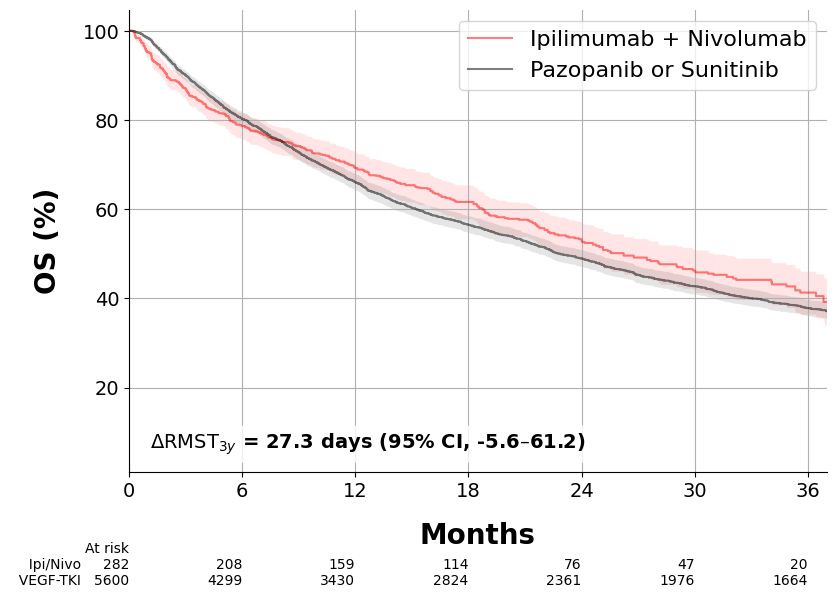

In [24]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# ipi/nivo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Ipilimumab + Nivolumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# tki estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Pazopanib or Sunitinib')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 37, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 37 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 3 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][1095]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{3y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['Ipi/Nivo', 'VEGF-TKI'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

plt.savefig('../outputs/os_ioio_tki.pdf', format='pdf', bbox_inches='tight')